<a href="https://colab.research.google.com/github/athfizh/PemMes26_05_Hafizh/blob/main/JS05/JS05-TugasLab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---


# **Klasifikasi 1 - Tugas Lab 1**


---

**Klasifikasi jenis suara `male` dan `female` pada dataset `voice.csv` menggunakan kNN**

Tugas yang dikerjakan,

1. Membuat model klasifikasi kNN untuk mengklasifikasikan jenis suara `male` dan `female`.
2. Melakukan percobaan untuk menentukan fitur yang paling optimal.
3. Menentukan nilai k terbaik berdasarkan fitur terpilih beserta grafik analisis dan alasannya.

---


# **Langkah 1 - Load Data**


---

In [1]:
# Load data
import pandas as pd
data = pd.read_csv('/content/voice.csv')
data.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


---


# **Langkah 2 - Eksplorasi Data**


---

In [2]:
data.info()
print('\n')
print('Jumlah data kosong:', data.isnull().sum().sum())
print('\n')
print(data['label'].value_counts())
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx
count,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000
mean,0.180907,0.057126,0.185621,0.140456,0.224765,0.084309,3.140168,36.568461,0.895127,0.408216,0.165282,0.180907,0.142807,0.036802,0.258842,0.829211,0.052647,5.047277,4.994630,0.173752
std,0.029918,0.016652,0.036360,0.048680,0.023639,0.042783,4.240529,134.928661,0.044980,0.177521,0.077203,0.029918,0.032304,0.019220,0.030077,0.525205,0.063299,3.521157,3.520039,0.119454
min,0.039363,0.018363,0.010975,0.000229,0.042946,0.014558,0.141735,2.068455,0.738651,0.036876,0.000000,0.039363,0.055565,0.009775,0.103093,0.007812,0.004883,0.007812,0.000000,0.000000
25%,0.163662,0.041954,0.169593,0.111087,0.208747,0.042560,1.649569,5.669547,0.861811,0.258041,0.118016,0.163662,0.116998,0.018223,0.253968,0.419828,0.007812,2.070312,2.044922,0.099766
50%,0.184838,0.059155,0.190032,0.140286,0.225684,0.094280,2.197101,8.318463,0.901767,0.396335,0.186599,0.184838,0.140519,0.046110,0.271186,0.765795,0.023438,4.992188,4.945312,0.139357
75%,0.199146,0.067020,0.210618,0.175939,0.243660,0.114175,2.931694,13.648905,0.928713,0.533676,0.221104,0.199146,0.169581,0.047904,0.277457,1.177166,0.070312,7.007812,6.992188,0.209183
max,0.251124,0.115273,0.261224,0.247347,0.273469,0.252225,34.725453,1309.612887,0.981997,0.842936,0.280000,0.251124,0.237636,0.204082,0.279114,2.957682,0.458984,21.867188,21.843750,0.932374


---


# **Langkah 3 - Visualisasi Data**


---

Pertama, kita lihat distribusi setiap fitur pada masing-masing kelas. Fitur yang distribusinya terpisah jelas antara `male` dan `female` berpotensi menjadi fitur yang baik.

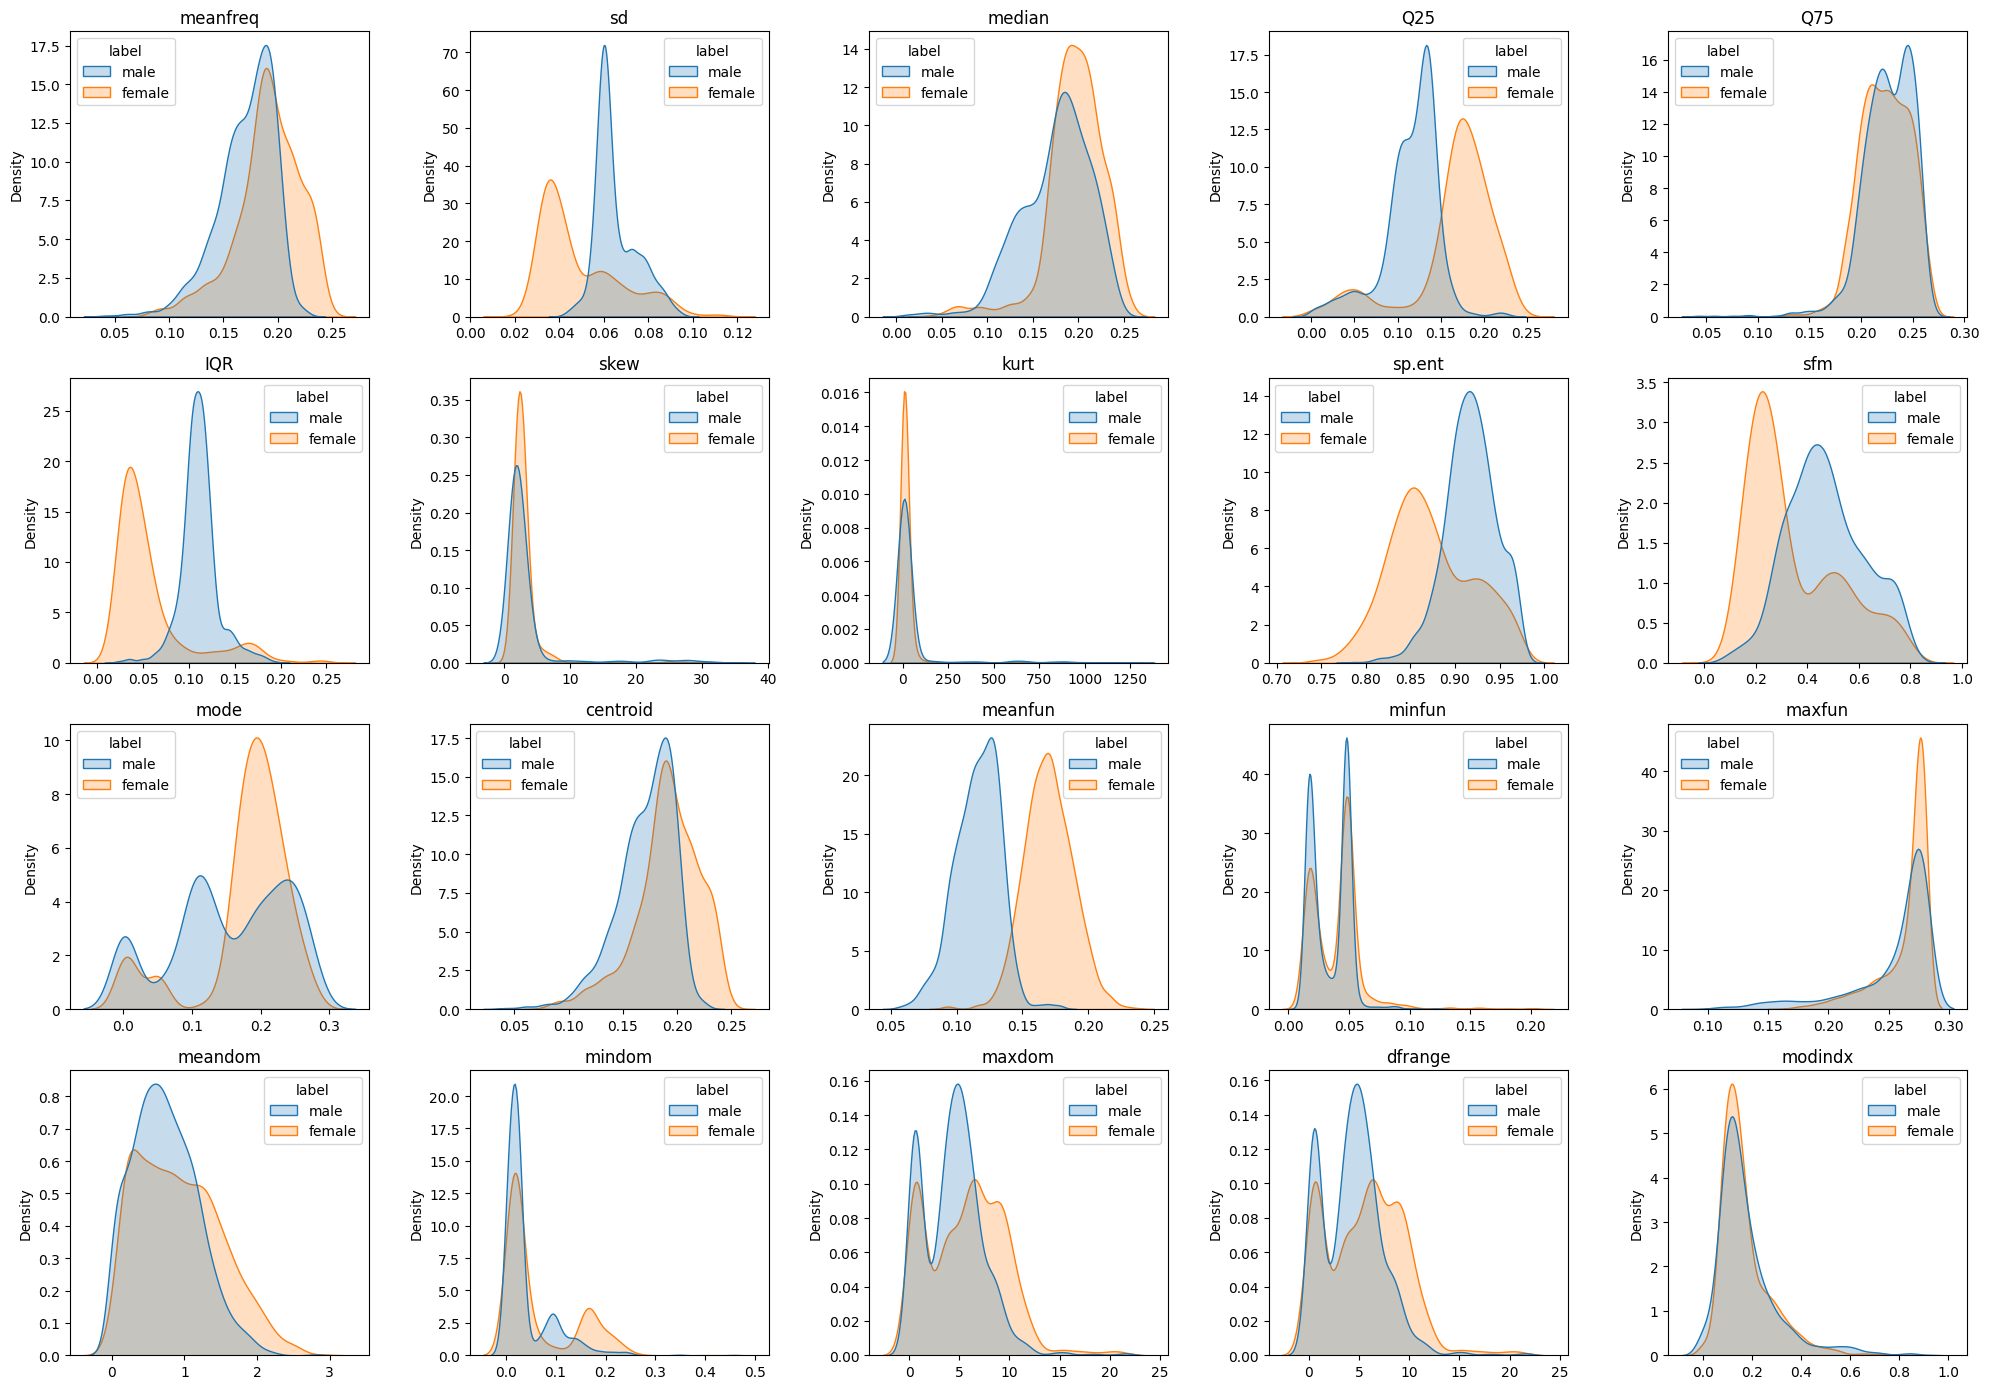

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

fitur = data.columns[:-1]

fig, axes = plt.subplots(4, 5, figsize=(20, 14))
for ax, f in zip(axes.ravel(), fitur):
    sns.kdeplot(data=data, x=f, hue='label', fill=True, common_norm=False, ax=ax, warn_singular=False)
    ax.set_title(f)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

Selanjutnya kita lihat korelasi antar fitur. Fitur yang berkorelasi sangat tinggi membawa informasi yang hampir sama (redundan).

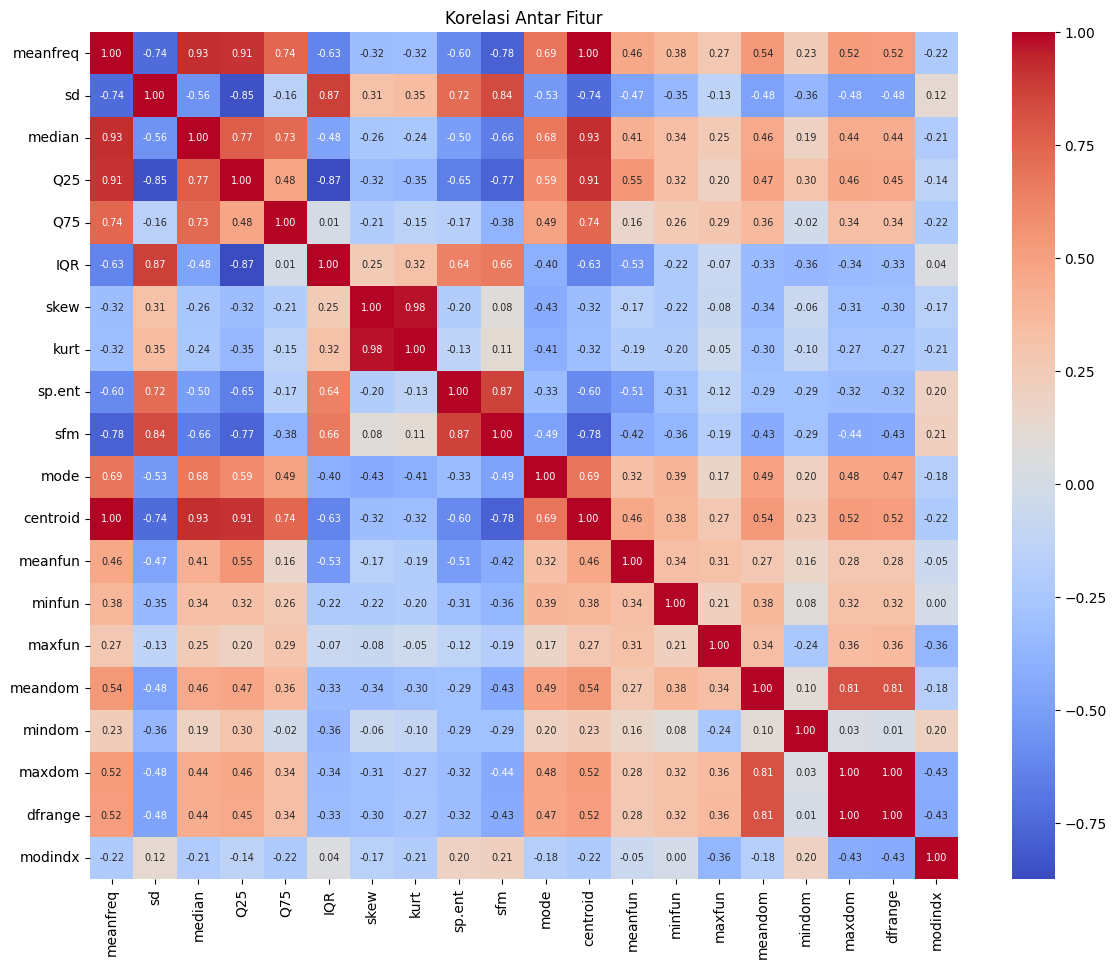

meanfreq identik dengan centroid: True


In [4]:
plt.figure(figsize=(14, 11))
sns.heatmap(data.drop(columns='label').corr(), annot=True, fmt='.2f', cmap='coolwarm', annot_kws={'size': 7})
plt.title('Korelasi Antar Fitur')
plt.show()

# Cek apakah kolom meanfreq dan centroid identik
print('meanfreq identik dengan centroid:', (data['meanfreq'] == data['centroid']).all())

---


# **Langkah 4 - Preprocessing**


---

Pada tahap ini kita akan,

- Mengubah label `male` = 1 dan `female` = 0
- Memisahkan fitur dengan label
- Split data 70% training dan 30% testing dengan `stratify` agar proporsi kelas tetap seimbang
- Standardisasi fitur (kNN berbasis jarak sehingga sangat sensitif terhadap skala fitur)

Seluruh percobaan pemilihan fitur dan nilai k dilakukan **hanya dengan data training** (menggunakan cross-validation). Data testing baru dipakai untuk evaluasi akhir agar tidak terjadi kebocoran data.

In [5]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# Encode label
y = data['label'].map({'male': 1, 'female': 0})
X = data.drop(columns='label')

# Split data (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print('Data train:', X_train.shape)
print('Data test :', X_test.shape)

# Cross-validation 5-fold pada data training
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Fungsi bantu: akurasi rata-rata CV untuk fitur dan nilai k tertentu
# (standardisasi dilakukan di dalam pipeline agar tidak ada kebocoran data)
def cv_acc(fitur, k=5):
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    return cross_val_score(model, X_train[fitur], y_train, cv=cv).mean()

Data train: (2217, 20)
Data test : (951, 20)


---


# **Langkah 5 - Buat Model kNN (Soal 1)**


---

Sebagai pembanding, kita buat model kNN dengan **seluruh fitur** (20 fitur) dan k = 5.

In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

semua_fitur = X.columns.tolist()

# Standardisasi
scaler = StandardScaler()
X_train_all = scaler.fit_transform(X_train)
X_test_all = scaler.transform(X_test)

# Latih model
knn_all = KNeighborsClassifier(n_neighbors=5)
knn_all.fit(X_train_all, y_train)

y_pred = knn_all.predict(X_test_all)
print('Akurasi CV (train)  :', round(cv_acc(semua_fitur, 5), 4))
print('Akurasi data test   :', round(accuracy_score(y_test, y_pred), 4))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('Laporan Klasifikasi:\n', classification_report(y_test, y_pred, target_names=['female', 'male']))

Akurasi CV (train)  : 0.968
Akurasi data test   : 0.9737
Confusion Matrix:
 [[461  15]
 [ 10 465]]
Laporan Klasifikasi:
               precision    recall  f1-score   support

      female       0.98      0.97      0.97       476
        male       0.97      0.98      0.97       475

    accuracy                           0.97       951
   macro avg       0.97      0.97      0.97       951
weighted avg       0.97      0.97      0.97       951



---


# **Langkah 6 - Percobaan Pemilihan Fitur (Soal 2)**


---

Dua pendekatan dicoba untuk mencari fitur paling optimal, dengan k = 5 sebagai nilai sementara,

1. **Filter (ranking ANOVA F-score)**: fitur diurutkan berdasarkan kekuatan pemisahan kelas, lalu dicoba top-1, top-2, ..., top-20.
2. **Forward Selection**: mulai dari 0 fitur, lalu tambahkan satu fitur per langkah yang paling menaikkan akurasi CV. Pendekatan ini memperhitungkan interaksi antar fitur sehingga mampu menghindari fitur yang redundan.

**Langkah 6a - Ranking Fitur (Filter)**

In [7]:
from sklearn.feature_selection import f_classif

F, _ = f_classif(X_train, y_train)
ranking = pd.Series(F, index=X.columns).sort_values(ascending=False)
urutan_filter = ranking.index.tolist()

acc_filter = [cv_acc(urutan_filter[:n]) for n in range(1, 21)]

hasil_filter = pd.DataFrame({
    'Jumlah Fitur': range(1, 21),
    'Fitur Terakhir Ditambahkan': urutan_filter,
    'F-score': ranking.values.round(1),
    'Akurasi CV': np.round(acc_filter, 4)
})
hasil_filter

,Jumlah Fitur,Fitur Terakhir Ditambahkan,F-score,Akurasi CV
0,1,meanfun,4943.4,0.9441
1,2,IQR,1378.9,0.9689
2,3,Q25,777.7,0.9711
3,4,sp.ent,688.9,0.9698
4,5,sd,669.5,0.9761
5,6,sfm,336.6,0.9774
6,7,centroid,280.5,0.9752
7,8,meanfreq,280.5,0.9743
8,9,median,183.7,0.9756
9,10,mindom,86.6,0.9743


**Langkah 6b - Forward Selection**

In [8]:
terpilih = []
sisa = X.columns.tolist()
riwayat = []   # (fitur yang ditambahkan, akurasi CV)

while sisa:
    skor = {f: cv_acc(terpilih + [f]) for f in sisa}
    terbaik = max(skor, key=skor.get)
    terpilih.append(terbaik)
    sisa.remove(terbaik)
    riwayat.append((terbaik, skor[terbaik]))

urutan_forward = [r[0] for r in riwayat]
acc_forward = [r[1] for r in riwayat]

hasil_forward = pd.DataFrame({
    'Jumlah Fitur': range(1, 21),
    'Fitur yang Ditambahkan': urutan_forward,
    'Akurasi CV': np.round(acc_forward, 4)
})
hasil_forward

,Jumlah Fitur,Fitur yang Ditambahkan,Akurasi CV
0,1,meanfun,0.9441
1,2,IQR,0.9689
2,3,mode,0.9752
3,4,sfm,0.9793
4,5,sp.ent,0.9797
5,6,maxdom,0.9793
6,7,minfun,0.9806
7,8,skew,0.9811
8,9,dfrange,0.9806
9,10,kurt,0.9802


**Langkah 6c - Perbandingan dan Pemilihan Fitur**

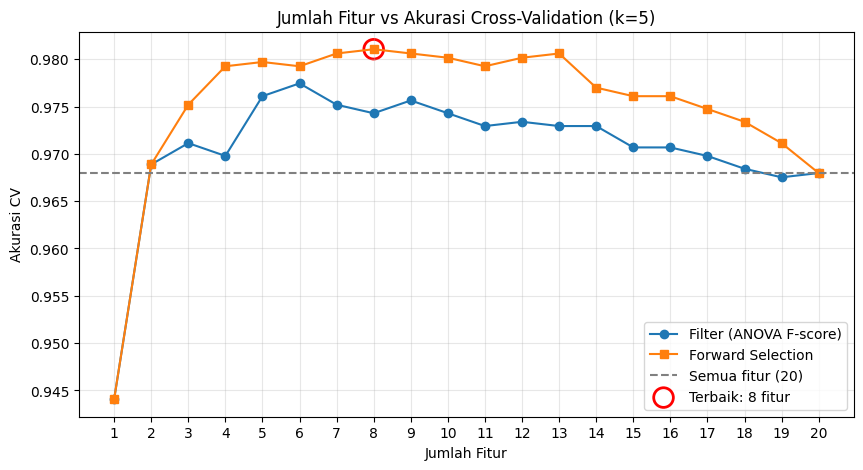

Jumlah fitur terbaik: 8
Fitur terpilih      : ['meanfun', 'IQR', 'mode', 'sfm', 'sp.ent', 'maxdom', 'minfun', 'skew']
Akurasi CV terbaik  : 0.9811
Akurasi CV semua fitur: 0.968
Akurasi CV terbaik filter: 0.9774 (top-6)


In [9]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), acc_filter, marker='o', label='Filter (ANOVA F-score)')
plt.plot(range(1, 21), acc_forward, marker='s', label='Forward Selection')
plt.axhline(cv_acc(semua_fitur), color='gray', linestyle='--', label='Semua fitur (20)')

n_terbaik = int(np.argmax(acc_forward)) + 1
plt.scatter(n_terbaik, max(acc_forward), s=200, facecolors='none', edgecolors='red', linewidths=2, label=f'Terbaik: {n_terbaik} fitur')

plt.title('Jumlah Fitur vs Akurasi Cross-Validation (k=5)')
plt.xlabel('Jumlah Fitur')
plt.ylabel('Akurasi CV')
plt.xticks(range(1, 21))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

fitur_terpilih = urutan_forward[:n_terbaik]
print('Jumlah fitur terbaik:', n_terbaik)
print('Fitur terpilih      :', fitur_terpilih)
print('Akurasi CV terbaik  :', round(max(acc_forward), 4))
print('Akurasi CV semua fitur:', round(cv_acc(semua_fitur), 4))
print('Akurasi CV terbaik filter:', round(max(acc_filter), 4), f'(top-{int(np.argmax(acc_filter)) + 1})')

---


# **Langkah 7 - Evaluasi Model dengan Fitur Terpilih**


---

In [10]:
# Standardisasi hanya pada fitur terpilih
scaler = StandardScaler()
X_train_sel = scaler.fit_transform(X_train[fitur_terpilih])
X_test_sel = scaler.transform(X_test[fitur_terpilih])

knn_sel = KNeighborsClassifier(n_neighbors=5)
knn_sel.fit(X_train_sel, y_train)

y_pred = knn_sel.predict(X_test_sel)
print('Akurasi data test (fitur terpilih, k=5):', round(accuracy_score(y_test, y_pred), 4))
print('Akurasi data test (semua fitur, k=5)    :', round(knn_all.score(X_test_all, y_test), 4))

Akurasi data test (fitur terpilih, k=5): 0.9811
Akurasi data test (semua fitur, k=5)    : 0.9737


---


# **Langkah 8 - Evaluasi Nilai k (Soal 3)**


---

Dengan fitur terpilih, kita evaluasi nilai k = 1 sampai 30. Nilai k terbaik dipilih berdasarkan **akurasi cross-validation pada data training**, bukan dari data testing, agar pemilihannya tidak bias. Akurasi data training dan testing ditampilkan sebagai pembanding untuk melihat kondisi underfitting/overfitting.

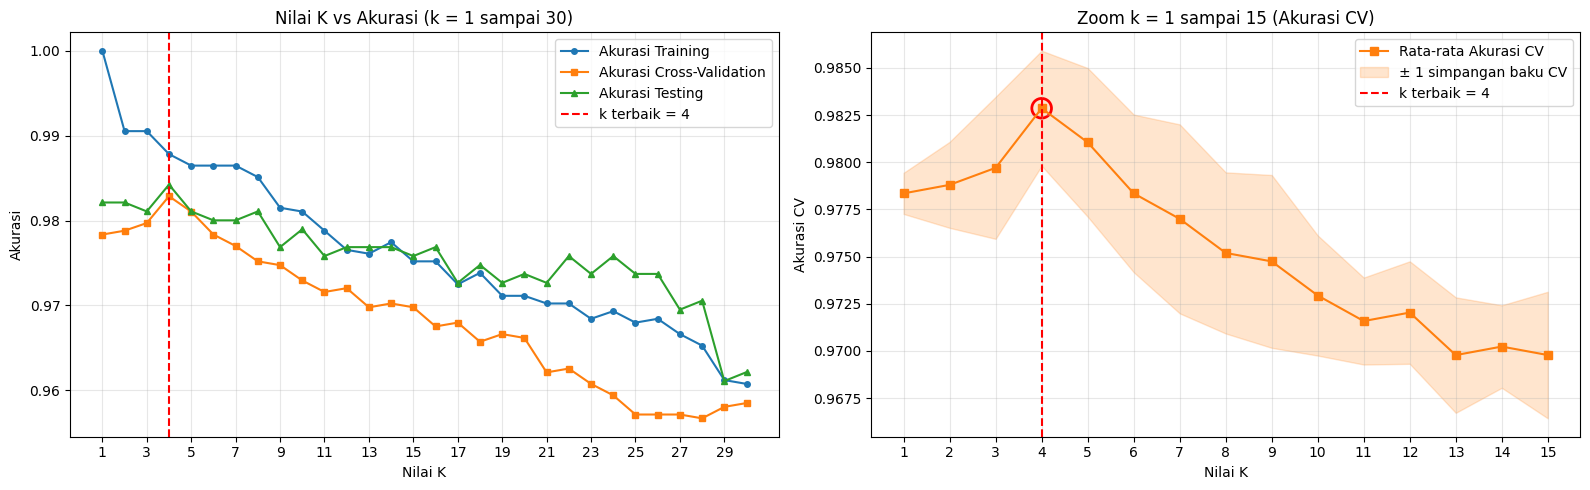

Nilai k terbaik (berdasarkan CV): 4


,K,Akurasi Training,Akurasi CV,Std CV,Akurasi Testing
3,4,0.9878,0.9829,0.0031,0.9842
4,5,0.9865,0.9811,0.0039,0.9811
2,3,0.9905,0.9797,0.0038,0.9811
1,2,0.9905,0.9788,0.0023,0.9821
5,6,0.9865,0.9784,0.0042,0.9800
0,1,1.0000,0.9783,0.0011,0.9821
6,7,0.9865,0.9770,0.0050,0.9800
7,8,0.9851,0.9752,0.0043,0.9811
8,9,0.9815,0.9747,0.0046,0.9769
9,10,0.9811,0.9729,0.0032,0.9790


In [11]:
k_range = range(1, 31)
acc_train, acc_cv, std_cv, acc_test = [], [], [], []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_sel, y_train)
    acc_train.append(model.score(X_train_sel, y_train))
    acc_test.append(model.score(X_test_sel, y_test))

    # Akurasi cross-validation (standardisasi di dalam pipeline)
    skor = cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)), X_train[fitur_terpilih], y_train, cv=cv)
    acc_cv.append(skor.mean())
    std_cv.append(skor.std())

acc_train, acc_cv, std_cv, acc_test = map(np.array, (acc_train, acc_cv, std_cv, acc_test))
k_terbaik = list(k_range)[int(np.argmax(acc_cv))]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel kiri: seluruh rentang k (1-30)
axes[0].plot(k_range, acc_train, marker='o', markersize=4, label='Akurasi Training')
axes[0].plot(k_range, acc_cv, marker='s', markersize=4, label='Akurasi Cross-Validation')
axes[0].plot(k_range, acc_test, marker='^', markersize=4, label='Akurasi Testing')
axes[0].axvline(k_terbaik, color='red', linestyle='--', label=f'k terbaik = {k_terbaik}')
axes[0].set_title('Nilai K vs Akurasi (k = 1 sampai 30)')
axes[0].set_xlabel('Nilai K')
axes[0].set_ylabel('Akurasi')
axes[0].set_xticks(range(1, 31, 2))
axes[0].legend()
axes[0].grid(alpha=0.3)

# Panel kanan: zoom k = 1-15 dengan simpangan baku CV
kz = np.array(list(k_range))[:15]
axes[1].plot(kz, acc_cv[:15], marker='s', color='tab:orange', label='Rata-rata Akurasi CV')
axes[1].fill_between(kz, (acc_cv - std_cv)[:15], (acc_cv + std_cv)[:15], color='tab:orange', alpha=0.2, label='± 1 simpangan baku CV')
axes[1].axvline(k_terbaik, color='red', linestyle='--', label=f'k terbaik = {k_terbaik}')
axes[1].scatter(k_terbaik, acc_cv[k_terbaik - 1], s=200, facecolors='none', edgecolors='red', linewidths=2)
axes[1].set_title('Zoom k = 1 sampai 15 (Akurasi CV)')
axes[1].set_xlabel('Nilai K')
axes[1].set_ylabel('Akurasi CV')
axes[1].set_xticks(range(1, 16))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

hasil_k = pd.DataFrame({'K': list(k_range), 'Akurasi Training': acc_train.round(4), 'Akurasi CV': acc_cv.round(4), 'Std CV': std_cv.round(4), 'Akurasi Testing': acc_test.round(4)})
print('Nilai k terbaik (berdasarkan CV):', k_terbaik)
hasil_k.sort_values('Akurasi CV', ascending=False).head(10)

---


# **Langkah 9 - Evaluasi Akhir**


---

Fitur  : ['meanfun', 'IQR', 'mode', 'sfm', 'sp.ent', 'maxdom', 'minfun', 'skew']
Nilai k: 4
Akurasi: 0.9842
Laporan Klasifikasi:
               precision    recall  f1-score   support

      female       0.98      0.99      0.98       476
        male       0.99      0.98      0.98       475

    accuracy                           0.98       951
   macro avg       0.98      0.98      0.98       951
weighted avg       0.98      0.98      0.98       951



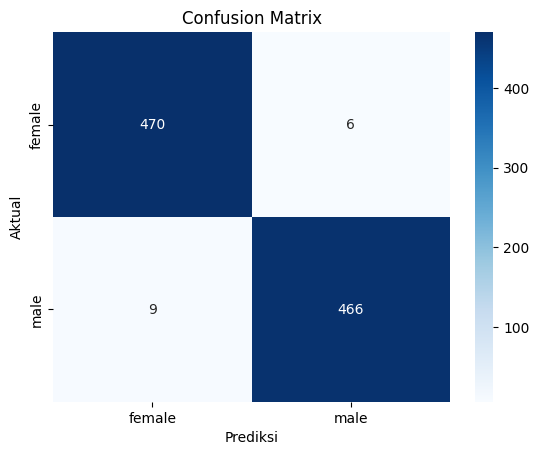

In [12]:
knn_final = KNeighborsClassifier(n_neighbors=k_terbaik)
knn_final.fit(X_train_sel, y_train)
y_pred = knn_final.predict(X_test_sel)

print('Fitur  :', fitur_terpilih)
print('Nilai k:', k_terbaik)
print('Akurasi:', round(accuracy_score(y_test, y_pred), 4))
print('Laporan Klasifikasi:\n', classification_report(y_test, y_pred, target_names=['female', 'male']))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=['female', 'male'], yticklabels=['female', 'male'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()

---


# **Kesimpulan**


---

**Jawaban Soal 1 - Model klasifikasi kNN**

Model kNN berhasil dibuat untuk mengklasifikasikan suara `male` dan `female`. Dengan seluruh fitur (20 fitur, k = 5), akurasi testing adalah 0.9737. Model akhir (fitur terpilih dan k terbaik) ada pada Langkah 9.

**Jawaban Soal 2 - Fitur yang paling optimal**

Fitur terbaik hasil percobaan (Forward Selection, 8 fitur) adalah,

`meanfun`, `IQR`, `mode`, `sfm`, `sp.ent`, `maxdom`, `minfun`, `skew`

| Percobaan | Jumlah Fitur | Akurasi CV (k=5) |
|---|---|---|
| Semua fitur | 20 | 0.9680 |
| Filter (ANOVA F-score) terbaik | 6 | 0.9774 |
| **Forward Selection terbaik** | **8** | **0.9811** |

Alasannya,

- Menggunakan semua fitur justru menurunkan akurasi karena banyak fitur yang redundan atau kurang informatif. Contohnya `meanfreq` dan `centroid` identik, serta `Q25`, `median`, dan `sd` saling berkorelasi kuat. Pada kNN yang berbasis jarak, fitur seperti ini ikut memengaruhi jarak antar data tanpa menambah informasi baru.
- `meanfun` (rata-rata frekuensi fundamental) adalah fitur paling kuat. Dengan satu fitur ini saja, akurasi CV sudah 0.9441.
- Forward Selection mengungguli ranking filter karena memilih fitur yang saling *melengkapi*, bukan sekadar fitur yang kuat secara individual. Contohnya `mode` dan `minfun` terpilih walaupun skor F-nya rendah, sedangkan `Q25` dan `sd` (skor F tinggi) tidak terpilih karena berkorelasi kuat dengan `IQR` (|r| sekitar 0.87) yang sudah terpilih lebih dulu.
- Akurasi CV mulai mendatar setelah sekitar 5 sampai 8 fitur, sehingga menambah fitur lagi tidak memberi manfaat.

**Jawaban Soal 3 - Nilai k terbaik (beserta grafik analisis)**

Grafik berikut adalah grafik analisis nilai k untuk 8 fitur terpilih pada soal nomor 2.

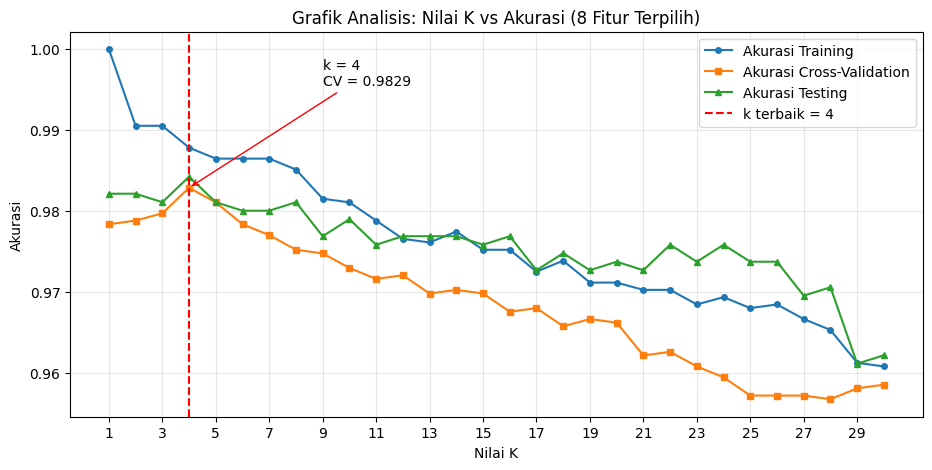

Nilai k terbaik: 4
Akurasi CV     : 0.9829
Akurasi Testing: 0.9842


In [13]:
# Grafik analisis nilai k (fitur terpilih pada Soal 2)
plt.figure(figsize=(11, 5))
plt.plot(k_range, acc_train, marker='o', markersize=4, label='Akurasi Training')
plt.plot(k_range, acc_cv, marker='s', markersize=4, label='Akurasi Cross-Validation')
plt.plot(k_range, acc_test, marker='^', markersize=4, label='Akurasi Testing')
plt.axvline(k_terbaik, color='red', linestyle='--', label=f'k terbaik = {k_terbaik}')
plt.annotate(f'k = {k_terbaik}\nCV = {acc_cv[k_terbaik - 1]:.4f}', xy=(k_terbaik, acc_cv[k_terbaik - 1]), xytext=(k_terbaik + 5, 0.9955), arrowprops=dict(arrowstyle='->', color='red'))
plt.title('Grafik Analisis: Nilai K vs Akurasi (8 Fitur Terpilih)')
plt.xlabel('Nilai K')
plt.ylabel('Akurasi')
plt.xticks(range(1, 31, 2))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('Nilai k terbaik:', k_terbaik)
print('Akurasi CV     :', round(acc_cv[k_terbaik - 1], 4))
print('Akurasi Testing:', round(acc_test[k_terbaik - 1], 4))

Berdasarkan fitur terpilih pada soal nomor 2, **nilai k terbaik adalah k = 4** (akurasi CV 0.9829, akurasi testing 0.9842).

Alasan berdasarkan grafik,

- **k kecil (overfitting):** pada k = 1 akurasi training sempurna (1.0), tetapi akurasi CV lebih rendah (0.9783). Model menghafal data training dan sensitif terhadap noise.
- **k besar (underfitting):** semakin besar k, akurasi CV cenderung turun (0.9585 pada k = 30) karena batas keputusan terlalu halus dan kehilangan detail pola.
- **k = 4:** memiliki akurasi CV tertinggi, dan selisih akurasi training dengan CV kecil (sekitar 0.005), sehingga model seimbang antara bias dan variansi.
- Pemilihan k didasarkan pada akurasi **cross-validation di data training**, bukan data testing, sehingga akurasi testing tetap menjadi ukuran yang jujur untuk data baru. Akurasi testing juga tertinggi pada k = 4, sehingga hasilnya konsisten.
- Catatan: selisih akurasi CV antara k = 3, 4, dan 5 sangat kecil (di bawah 0.4%) dan masih dalam rentang simpangan baku CV, sehingga k = 3 atau k = 5 juga hampir setara.

**Model akhir:** kNN dengan 8 fitur terpilih dan k = 4 mencapai akurasi testing **0.9842**, meningkat dibandingkan baseline 20 fitur (0.9737).